<a href="https://colab.research.google.com/github/S-Feranc/Bachelor-s-thesis/blob/main/yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/google-drive')

Mounted at /content/google-drive


In [ ]:
!nvidia-smi

Thu May  7 10:46:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
import os

HOME = os.getcwd()
print(HOME)

/content


In [ ]:
from IPython import display
import ultralytics

display.clear_output()
!yolo checks

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)

OS                     Linux-6.6.113+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.13
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   43.3/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅ 2.10.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32

In [ ]:
import os
import cv2
import numpy as np
import torch

from ultralytics import YOLO
from roboflow import Roboflow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="piFOmJWoc4cb9DSQZddU")
project = rf.workspace("samuels-workspace-q2ohp").project("hornets-bagr9")
version = project.version(1)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hornets-1 in yolov8:: 100%|██████████| 10243/10243 [00:04<00:00, 2151.74it/s]


In [ ]:
!yolo task=detect mode=train model="yolov8n.pt" data={HOME}/hornets-1/data.yaml epochs=30 imgsz=320 patience=7 device=0

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hornets-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=7, persp

In [ ]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={HOME}/hornets-1/data.yaml epochs=30 imgsz=320 patience=7 device=0

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1699.5±610.5 MB/s, size: 63.9 KB)
val: Scanning /content/hornets-1/valid/labels.cache... 431 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 431/431 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 7.4it/s 3.7s
                   all        431        503      0.906       0.89      0.946      0.728
          Vespa_crabro        171        194      0.902      0.871      0.937      0.723
        Vespa_velutina        157        167      0.941      0.934      0.974      0.743
      Vespula_vulgaris        109        142      0.876      0.866      0.927      0.719
Speed: 0.5ms preprocess, 1.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more

In [ ]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={HOME}/hornets-1/data.yaml split=test imgsz=320 device=0

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1886.2±594.2 MB/s, size: 57.1 KB)
val: Scanning /content/hornets-1/test/labels... 290 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 290/290 2.2Kit/s 0.1s
val: New cache created: /content/hornets-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.5it/s 3.4s
                   all        290        348      0.924      0.857      0.949      0.697
          Vespa_crabro        120        135       0.97      0.904      0.986      0.749
        Vespa_velutina        111        122      0.942      0.932      0.981      0.728
      Vespula_vulgaris         60         91      0.859      0.734      0.879      0.614
Speed: 0.7ms preprocess, 2.3ms inference, 0.0ms loss, 3.5ms postprocess per image
R

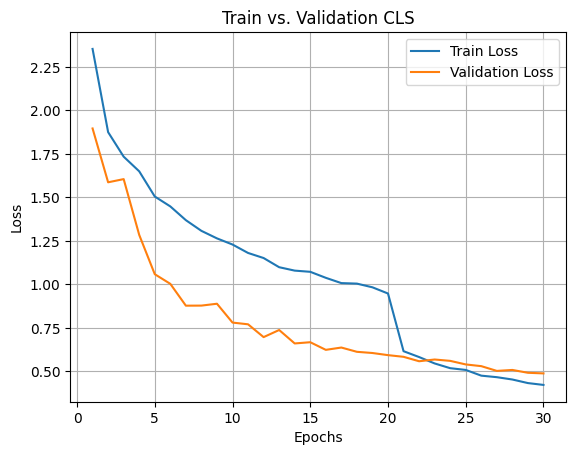

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


#results_file = "/content/google-drive/MyDrive/Bakalarka_colab/Verzia3_small/runs/detect/train/results.csv"
results_file = "/content/runs/detect/train/results.csv"


data = pd.read_csv(results_file)

# Assuming no header row (adjust if needed)
data.columns = ["epoch", "time", "train/box_loss", "train/cls_loss", "train/dfl_loss",
                "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                "val/box_loss", "val/cls_loss", "val/dfl_loss", "lr/pg0", "lr/pg1", "lr/pg2"]

# Extract data
train_epochs = data["epoch"]
train_cls_loss = data["train/cls_loss"]
val_epochs = data["epoch"]
val_cls_loss = data["val/cls_loss"]

# Plot the loss
plt.plot(train_epochs, train_cls_loss, label="Train Loss")
plt.plot(val_epochs, val_cls_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs. Validation CLS")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!yolo export model=/content/runs/detect/train/weights/best.pt format=onnx imgsz=320


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.0s, saved as '/content/runs/detect/train/weights/best.onnx' (11.6 MB)

Export complete (1.3s)
Results saved to /content/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=320 data=/content/hornets-1/data.yaml  
Visualize:       https://netron.app
💡 Learn more at https://docs.ultralytics.com/modes/export


In [ ]:
!yolo export model=/content/runs/detect/train/weights/best.pt format=tflite imgsz=320

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.1s, saved as '/content/runs/detect/train/weights/best.onnx' (11.6 MB)
E0000 00:00:1778029411.095021    9918 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778029411.108578    9918 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778029411.154242    9918 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking th

In [ ]:

!yolo export model=/content/runs/detect/train/weights/best.pt format=tflite imgsz=320 half=True


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.2s, saved as '/content/runs/detect/train/weights/best.onnx' (11.6 MB)
E0000 00:00:1778029442.389141   10086 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778029442.394764   10086 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778029442.412407   10086 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking th

In [ ]:
!yolo export model=/content/runs/detect/train/weights/best.pt format=tflite imgsz=320 int8=True data=/content/hornets-1/data.yaml

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/hornets-1/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 2509.3±718.0 MB/s, size: 66.6 KB)
Scanning /content/hornets-1/valid/labels.cache... 431 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 431/431 86.1Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.0s, saved as '/content/runs/detect/train/weights/best.onnx' (11.6 MB)
E0000 00:00:1778029475.497613   10248 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778

In [ ]:
!yolo export model=/content/runs/detect/train/weights/best.pt format=torchscript imgsz=320

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 1.6s, saved as '/content/runs/detect/train/weights/best.torchscript' (11.8 MB)

Export complete (1.9s)
Results saved to /content/runs/detect/train/weights/best.torchscript
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.torchscript imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.torchscript imgsz=320 data=/content/hornets-1/data.yaml  
Visualize:       https://netron.app
💡 Learn more at https://docs.ultralytics.com/modes/export


In [ ]:
!cp -r /content/runs/detect /content/google-drive/MyDrive/diplomovka

In [ ]:
!cp -r /content/hornets-1/ /content/google-drive/MyDrive/diplomovka

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="/content/runs/detect/train/weights/best_saved_model/best_full_integer_quant.tflite"  # uprav cestu ak treba
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype :", input_details[0]["dtype"])
print("Output dtype:", output_details[0]["dtype"])
print("Quant input :", input_details[0]["quantization"])
print("Quant output:", output_details[0]["quantization"])
print(interpreter.get_output_details()[0]["shape"])


Input dtype : <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Quant input : (0.003921568859368563, -128)
Quant output: (0.004076667595654726, -128)
[   1    7 2100]


In [ ]:
import random
import shutil
from pathlib import Path


TEST_IMAGES_DIR = Path("/content/google-drive/MyDrive/diplomovka/hornets-1/test/images")
OUT_DIR = Path("/content/random_test_20")


OUT_DIR.mkdir(exist_ok=True)


images = list(TEST_IMAGES_DIR.glob("*.*"))


assert len(images) >= 20, "Test set má menej ako 20 obrázkov"


selected = random.sample(images, 20)


for img in selected:
    shutil.copy(img, OUT_DIR / img.name)

print("Skopírovaných 20 náhodných testovacích obrázkov do:", OUT_DIR)

✅ Skopírovaných 20 náhodných testovacích obrázkov do: /content/random_test_20


In [ ]:
!cp -r /content/random_test_20 /content/google-drive/MyDrive/diplomovka

➡️ Validujem: PyTorch (.pt)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1367.0±472.5 MB/s, size: 56.2 KB)
val: Scanning /content/hornets-1/valid/labels.cache... 431 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 431/431 139.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 9.9it/s 2.7s
                   all        431        503      0.906       0.89      0.946      0.728
Speed: 0.4ms preprocess, 1.6ms inference, 0.0ms loss, 1.3ms postprocess per image
➡️ Validujem: TorchScript
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/runs/detect/train/weights/best.torchscript for TorchScript inference...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1813.3±675.7 MB/s, size: 57.7 KB)
val: Scann

    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 431/431 26.8it/s 16.1s
                   all        431        503      0.903      0.897      0.947       0.72
Speed: 0.3ms preprocess, 31.6ms inference, 0.0ms loss, 0.7ms postprocess per image
➡️ Validujem: TFLite FP16
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/runs/detect/train/weights/best_saved_model/best_float16.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 320, 320)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1339.5±430.8 MB/s, size: 45.1 KB)
val: Scanning /content/hornets-1/valid/labels.cache... 431 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 431/431 53.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 431/431 26.5it/s 16.3s
                   all        431        503      0.902      0.897      0.947 

,Format,mAP50-95,Recall,Size_MB
0,PyTorch (.pt),0.7279,0.8905,5.9197
1,TorchScript,0.7197,0.8965,11.7803
2,ONNX,0.7197,0.8965,11.5783
3,TFLite FP32,0.7197,0.8965,11.5691
4,TFLite FP16,0.7204,0.8965,5.8255
5,TFLite INT8,0.7155,0.8881,3.0837


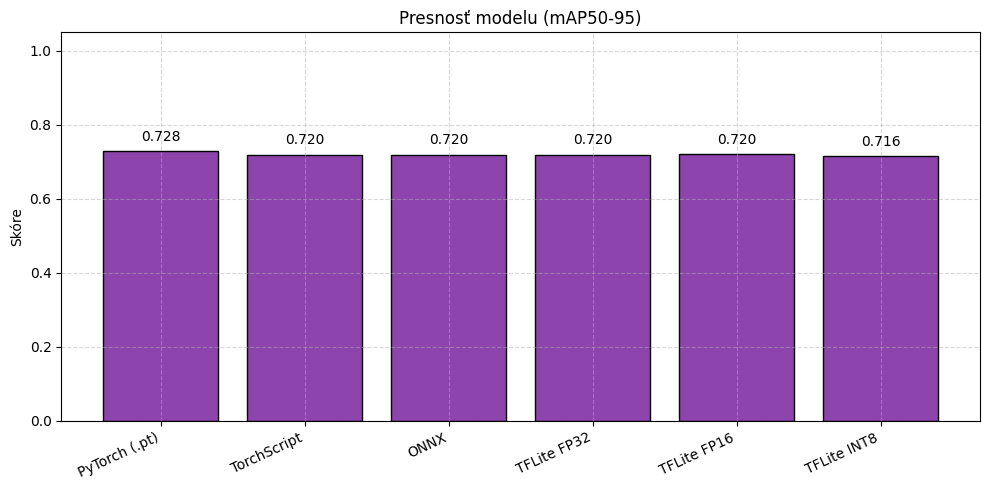

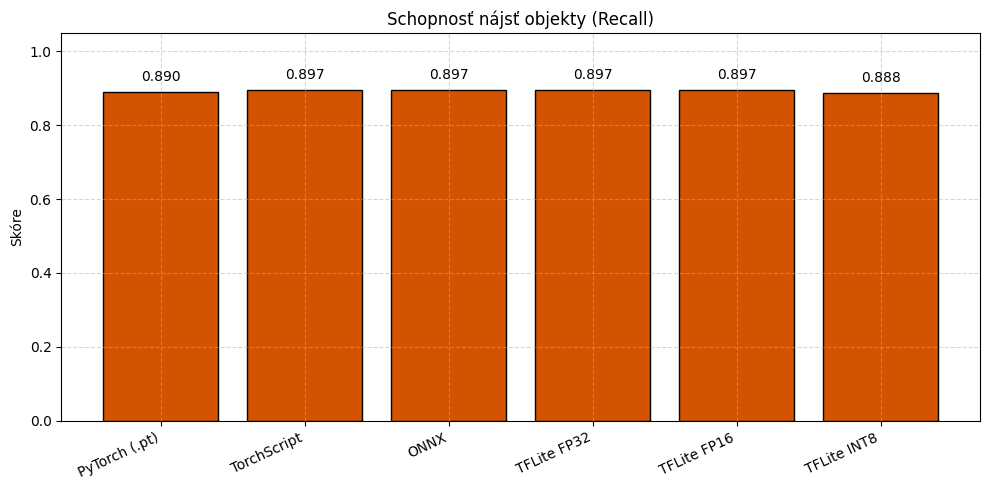

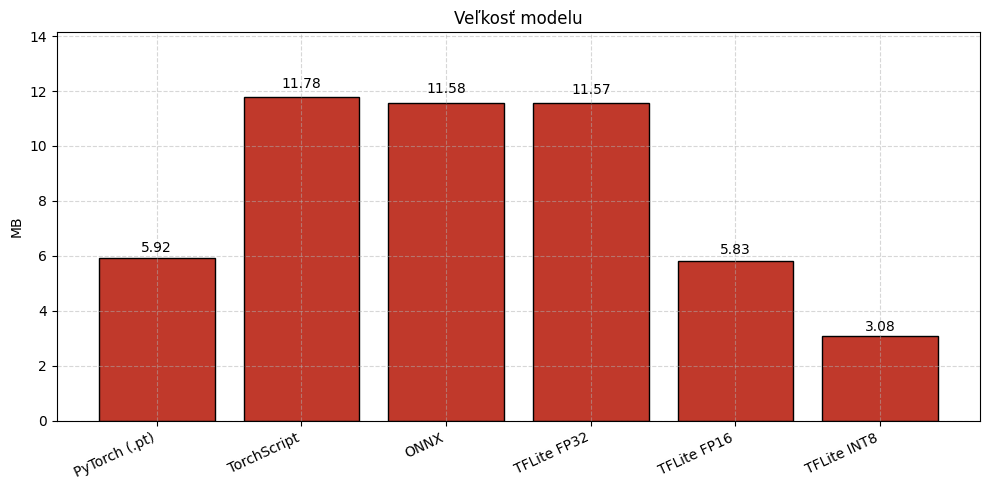

In [ ]:
%matplotlib inline

import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display

# 1. KONFIGURÁCIA
DATASET_PATH = '/content/hornets-1/data.yaml'
IMGSZ = 320

models_to_test = {
    'PyTorch (.pt)': '/content/runs/detect/train/weights/best.pt',
    'TorchScript': '/content/runs/detect/train/weights/best.torchscript',
    'ONNX': '/content/runs/detect/train/weights/best.onnx',
    'TFLite FP32': '/content/runs/detect/train/weights/best_saved_model/best_float32.tflite',
    'TFLite FP16': '/content/runs/detect/train/weights/best_saved_model/best_float16.tflite',
    'TFLite INT8': '/content/runs/detect/train/weights/best_saved_model/best_full_integer_quant.tflite'
}

# 2. VALIDÁCIA
def validate_all_models(models, dataset_yaml):
    results_list = []

    for name, path in models.items():
        if not os.path.exists(path):
            print(f"⚠️ {name} nenájdený, preskakujem...")
            continue

        print(f"➡️ Validujem: {name}")
        model = YOLO(path, task='detect')

        results = model.val(
            data=dataset_yaml,
            imgsz=IMGSZ,
            split='val',
            conf=0.001,
            verbose=False,
            plots=False
        )

        results_list.append({
            'Format': name,
            'mAP50-95': results.box.map,
            'Recall': results.box.mr,
            'Size_MB': os.path.getsize(path) / (1024 * 1024)
        })

    return pd.DataFrame(results_list)

# 3. SPUSTENIE
df = validate_all_models(models_to_test, DATASET_PATH)

# 4. ULOŽENIE
df.to_csv('porovnanie_exportov.csv', index=False)

# 5. ZOBRAZENIE
display(df.round(4))


# 6. GRAFY
def plot_metric(df, column, title, color, ylabel, is_accuracy=True):
    plt.figure(figsize=(10, 5))

    bars = plt.bar(df['Format'], df[column], color=color, edgecolor='black')

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=25, ha='right')

    plt.grid(True, linestyle='--', alpha=0.5)

    if is_accuracy:
        plt.ylim(0, 1.05)
    else:
        plt.ylim(0, df[column].max() * 1.2)

    for bar in bars:
        height = bar.get_height()
        offset = 0.02 if is_accuracy else height * 0.02
        plt.text(bar.get_x() + bar.get_width()/2., height + offset,
                 f'{height:.3f}' if is_accuracy else f'{height:.2f}',
                 ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


# 7. LEN PODSTATNÉ GRAFY
plot_metric(df, 'mAP50-95', 'Presnosť modelu (mAP50-95)', '#8e44ad', 'Skóre')
plot_metric(df, 'Recall', 'Schopnosť nájsť objekty (Recall)', '#d35400', 'Skóre')
plot_metric(df, 'Size_MB', 'Veľkosť modelu', '#c0392b', 'MB', is_accuracy=False)

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/google-drive/MyDrive/diplomovka/train/weights/best.pt')  # Tvoj model

# Vypíše štruktúru vrstiev
for i, layer in enumerate(model.model.model):
    print(f"Layer {i}: {layer}")

Layer 0: Conv(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Layer 1: Conv(
  (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Layer 2: C2f(
  (cv1): Conv(
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(16, 16, kernel_size=(3, 3), strid